# 산점도 그리기

In [1]:
import gdown

gdown.download('https://bit.ly/3pK7iuu', 'ns_book7.csv', quiet=False)

Downloading...
From: https://bit.ly/3pK7iuu
To: /content/ns_book7.csv
100%|██████████| 53.8M/53.8M [00:00<00:00, 119MB/s]


'ns_book7.csv'

In [2]:
import pandas as pd

ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)
ns_book7.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


전체 데이터를 한눈에 이해할 때는 그래프를 활용하는 것이 가장 효과적임.

대표적으로 데이터를 시각적으로 요약할 수 있는 그래프로는
산점도(scatter plot), 히스토그램(histogram), 상자수염그림(box-and-whisker plot) 등이 있음.

이 그래프들을 활용하면 데이터의 분포, 관계, 이상치 등을 더 직관적으로 파악할 수 있음.

## 산점도 그리기

산점도(scatter plot)는 데이터를 좌표평면 위에 점 형태로 표시하는 그래프임.

쉽게 말하면 두 변수(특성)의 값을 x축과 y축에 놓고 데이터들을 점으로 뿌려서 표현하는 방식임.
그래서 변수 사이의 관계나 패턴을 파악할 때 많이 사용함.

파이썬에서 그래프를 그릴 때는 보통 matplotlib 패키지를 사용함.
데이터 과학 분야에서 가장 많이 쓰이는 시각화 라이브러리 중 하나라서 구글 코랩에도 기본으로 설치되어 있음.

## scatter() 함수

산점도는 scatter() 함수를 사용해서 그림.

첫 번째 매개변수에는 x축 값, 두 번째 매개변수에는 y축 값을 넣으면 됨.
예를 들어 x축 좌표 4개와 y축 좌표 4개를 전달하면 각 좌표 위치에 점이 표시됨.

그리고 scatter()만 호출해서는 그래프가 바로 출력되지 않기 때문에 마지막에 show() 함수를 함께 호출해야 그래프가 화면에 나타남.

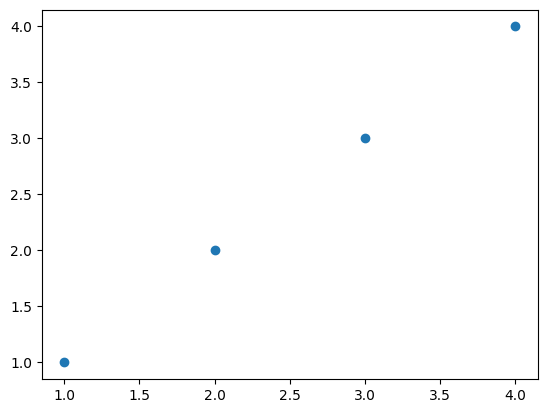

In [3]:
import matplotlib.pyplot as plt

plt.scatter([1,2,3,4], [1,2,3,4])
plt.show()

파이썬 스크립트나 대화형 셀(interactive shell) 환경에서는 show() 함수를 호출해야 그래프가 실제로 출력됨.

반면 최신 주피터 노트북이나 구글 코랩은 코드 셀이 끝날 때 자동으로 show()를 실행해주기 때문에 직접 호출하지 않아도 그래프가 나타남.

하지만 실행 환경에 상관없이 일관된 코드 작성 습관을 위해 여기서는 show() 함수를 함께 사용하는 방식으로 진행함.

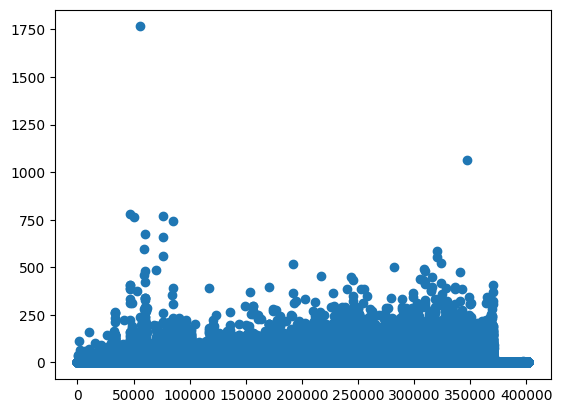

In [4]:
plt.scatter(ns_book7['번호'], ns_book7['대출건수'])
plt.show()

출력된 산점도를 보면 점들이 많이 겹쳐 있고, x축인 '번호' 값을 따라 특별한 패턴 없이 퍼져 있는 것을 확인할 수 있음.

사실 '번호' 열은 각 데이터를 구분하기 위해 붙인 일련번호일 뿐이라서 자체적인 의미는 거의 없음.
즉 번호가 크거나 작다고 해서 대출 건수가 달라질 이유가 없음.

그래서 산점도에서도 대출건수(y축)가 번호(x축)에 따라 일정한 경향성을 보이지 않고 전체적으로 고르게 퍼져 있는 형태로 나타남.

'번호' 열 대신 '도서권수'와 '대출건수' 사이의 관계를 산점도로 확인해봄.

scatter() 함수의 첫 번째 매개변수에는 x축으로 사용할 '도서권수' 열을 넣고,
두 번째 매개변수에는 y축으로 사용할 '대출건수' 열을 넣으면 됨.

이렇게 하면 도서권수가 많아질수록 대출건수가 어떻게 변하는지 시각적으로 확인할 수 있음.

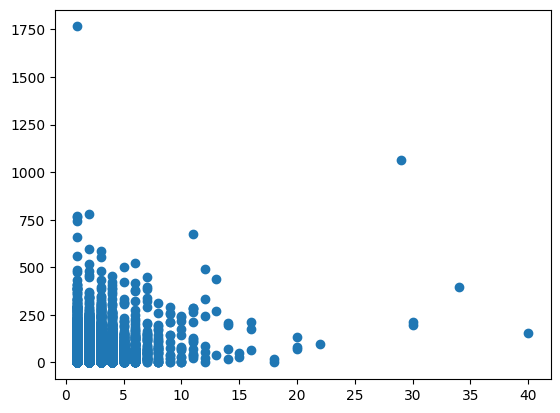

In [5]:
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'])
plt.show()

도서권수가 많으면 대출건수도 많을것이라 예상하기 쉽지만, 앞의 산점도를 보면 이런 경향을 파악하기 쉽지 않음

특히 대부분의 데이터가 도서권수 1~2권 범위에 몰려 있어서 왼쪽 아래 부분에 점들이 많이 겹쳐서 표시됨.

-> 단점도에 투명도를 주기

## 투명도 조절하기

맷플롯립은 alpha 매개변수에 0~1 사이의 값으로 투명도 지정 가능

투명도를 주더라도 데이터가 많이 중첩된 부분은 짙게 나타남\
이 매개변수를 0.1로 지정하여 산점도 그리기

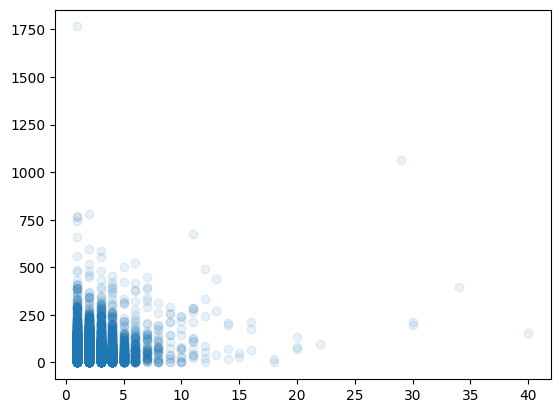

In [7]:
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

산점도에 투명도를 적용해도 왼쪽 아래 부분이 진하게 보이는 것은 데이터가 그 구간에 많이 몰려 있다는 뜻임.

즉 대부분의 도서권수가 적다는 의미이며, 실제로 describe() 결과에서도 도서권수의 90% 값이 2였기 때문에 대부분의 도서는 2권 이하인 것을 확인할 수 있음.

도서권수가 작은 값에 몰려 있어서 산점도만으로는 도서권수와 대출건수의 관계를 파악하기 어려움.

보통 도서권수가 많을수록 대출건수도 많아지는 관계를 **양의 상관관계**라고 하고,
반대로 도서권수가 적을수록 대출건수가 많아지는 관계를 **음의 상관관계**라고 함.

대출건수 열을 도서권수 열로 나눈 값을 average_borrows 변수에 저장하고 이 변수와 대출건수 열을 차례대로 scatter() 함수에 전달

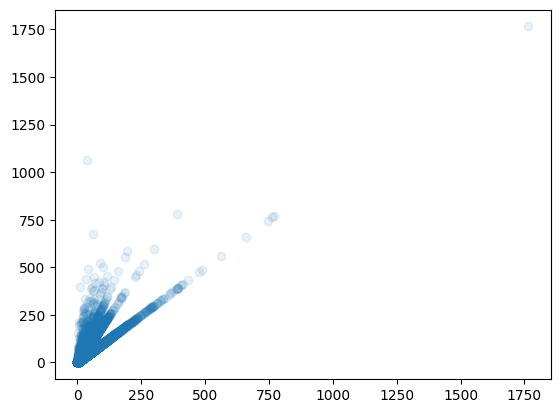

In [8]:
average_borrows = ns_book7['대출건수']/ns_book7['도서권수']
plt.scatter(average_borrows, ns_book7['대출건수'], alpha=0.1)
plt.show()

출력된 그래프를 보면 x축(도서권수 당 대출건수)이 증가함에 따라 y축(대출건수)이 증가\
두 특성 = 양의 상관관계

## 히스토그램 그리기
: 수치형 특성의 값을 일정한 구간(bin)으로 나누어 구간 안에 포함된 데이터 개수를 막대 그래프로 표현


 도수(frequency) - 구간 안에 속한 데이터 개수
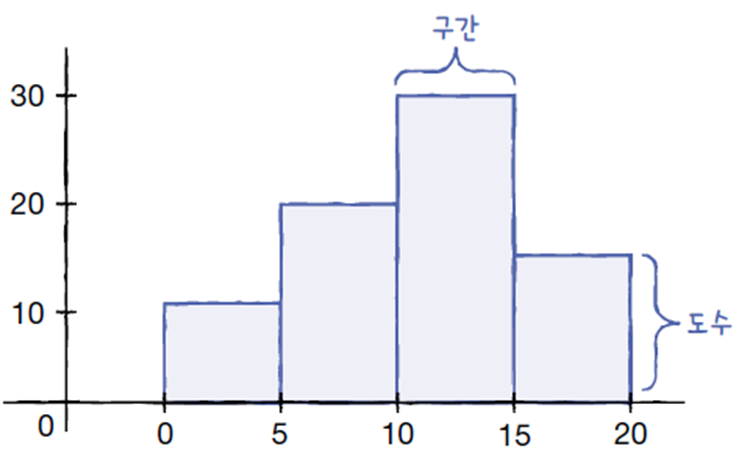

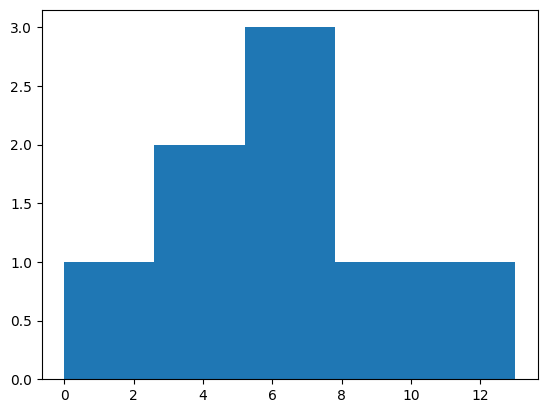

In [9]:
plt.hist([0,3,5,6,7,7,9,13], bins=5)
plt.show()

In [11]:
# histogram_bin_edges()함수로 구간 확인하기
import numpy as np
np.histogram_bin_edges([0,3,5,6,7,7,9,13], bins=5)

array([ 0. ,  2.6,  5.2,  7.8, 10.4, 13. ])

In [12]:
# randn()함수로 표준정규분포를 따르는 랜덤한 실수 생성 가능
# 함수에 샘플 개수를 전달하여 난수를 생성
np.random.seed(42)
random_samples =np.random.randn(1000)

위 코드는 랜덤한 실수 1,000개 생성\
seed()함수를 사용하면 유사난수를 생성 가능(즉, 가짜 난수)

In [13]:
print(np.mean(random_samples), np.std(random_samples))

0.01933205582232549 0.9787262077473543


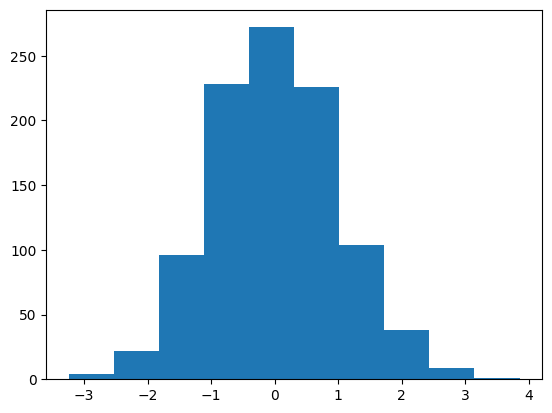

In [14]:
plt.hist(random_samples)
plt.show()

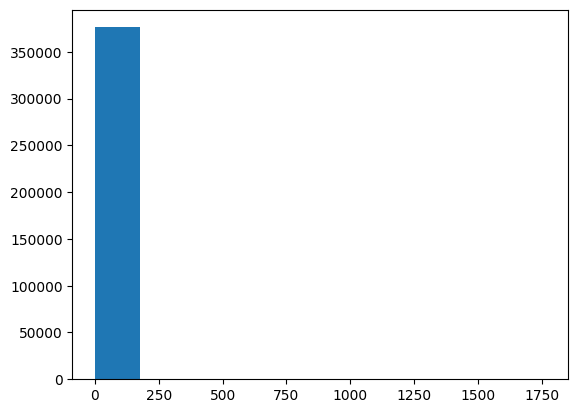

In [15]:
plt.hist(ns_book7['대출건수'])
plt.show()

- 산점도에서 봤듯이 대부분 도서의 대출건수는 작음
- describe() 메서드로 확인한 대출건수 열의 90% 백분위에 해당하는 값은 28에 불과

-> 앞의 그림과 같이 첫번째 구간의 도수가 너무 커서 다른 구간에논 도수값이 표시되지 않는 현상 발생

##구간조정하기
한 구간의 도수가 너무 커서 다른 구간에는 도수가 표시되지 않는 현상이 발생
y축을 로그스케일(log scale)로 바꾸어 해결

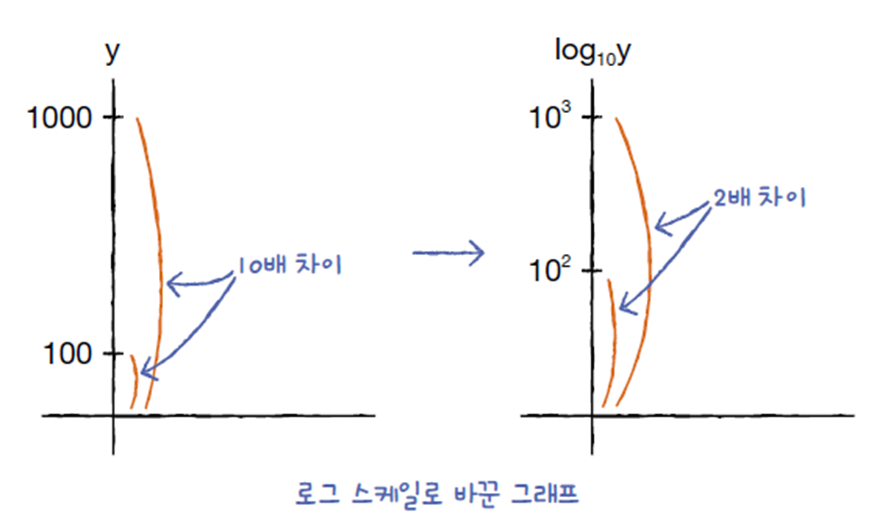

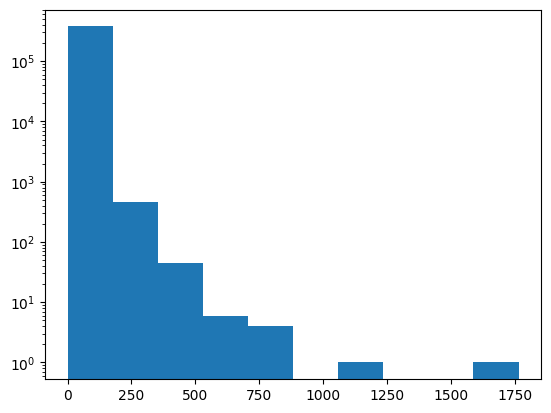

In [16]:
plt.hist(ns_book7['대출건수'])
plt.yscale('log')
plt.show()

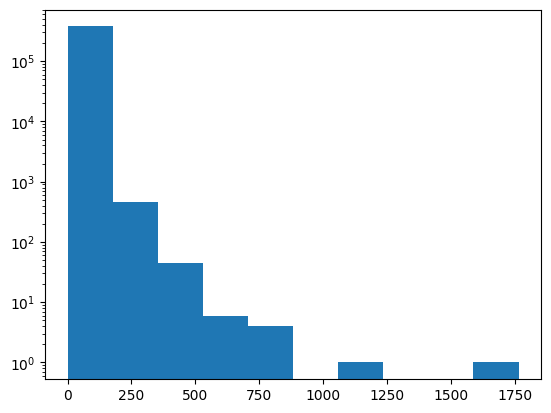

In [17]:
plt.hist(ns_book7['대출건수'], log=True)
plt.show()

맷플롯립은 기본적으로 밑이 10인 로그함수를 사용함

그래서 축 눈금이 10^0, 10^1, 10^2
 같은 형태로 표시되며,
값을 읽을 때는 지수 부분을 고려해서 해석하면 됨.

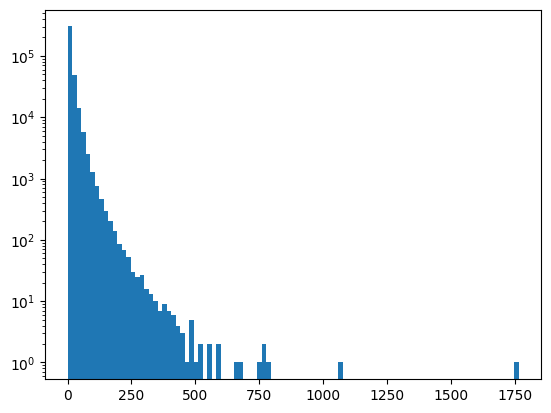

In [18]:
# x축의 구간을 더 세세하게 나눠보기
# hist() : 기본 10개 구간 사용
# bins 매개변수로 조정

plt.hist(ns_book7['대출건수'], bins=100)
plt.yscale('log')
plt.show()

대출건수가 0이 가장 많고 증가함에 따라 도수가 줄어듦 -> 정규분포와는 거리가 멀다.

도서명 열에 apply() 메서드를 사용하여 파이썬의 len() 함수를 적용하면 title_len 변수는 각 도서명의 길이가 저장된 판다스 시리즈 객체가 됨

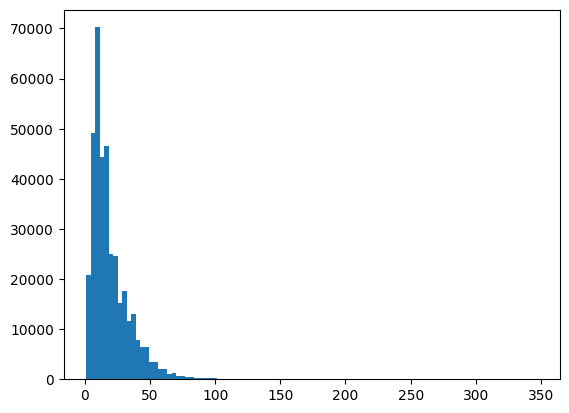

In [19]:
title_len = ns_book7['도서명'].apply(len)
plt.hist(title_len, bins=100)
plt.show()

x축에 데이터가 골고루 그려지도록 바꾸려면?\
y축에 로그 스케일을 적용했던 것처럼 x축에도 로그 스케일을 적용할 수 있음

y축에 로그스케일을 적용하는 yscale()함수와 비슷하게 xscale() 함수를 사용

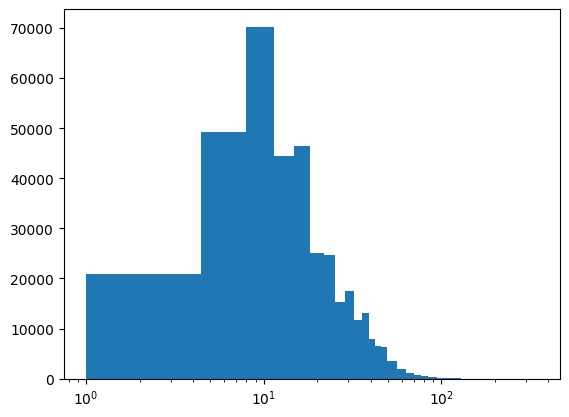

In [20]:
plt.hist(title_len, bins=100)
plt.xscale('log')
plt.show()

## 상자 수염 그림 그리기
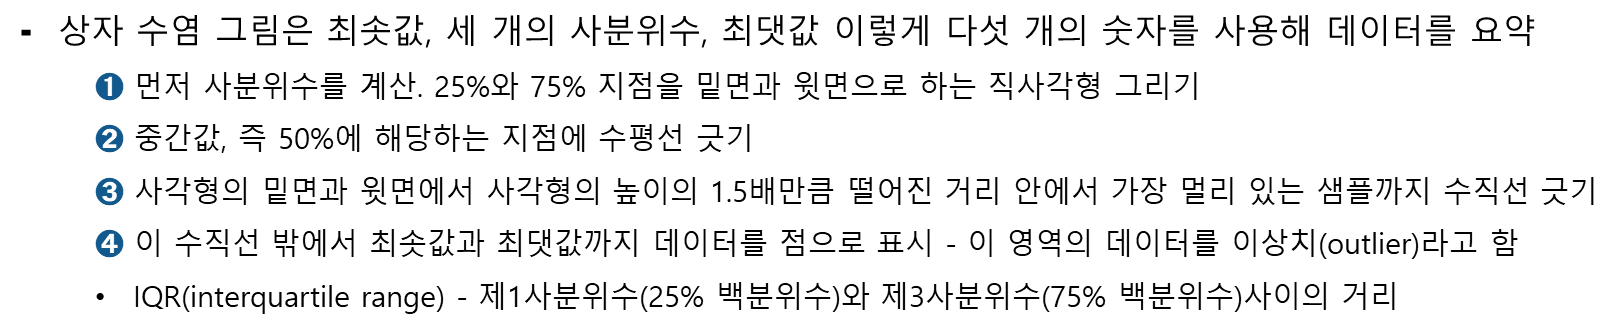
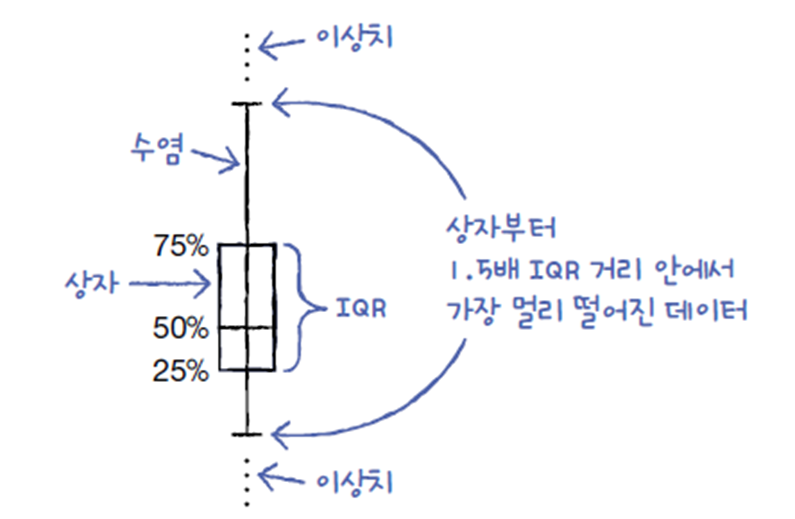

- 여러개의 특성을 시각적으로 비교하기 좋음
- 특히 데이터가 어떤 방향으로 더 많이 늘어져 있는지 한눈에 파악
- **이상치 값을 무조건적으로 제거하는 것은 아님**
- 이상치: 데이터 과학이나 머신러닝에서 관측 범위에서 아주 많이 벗어난 값 혹은 데이터에 내재한 패턴을 크게 벗어난 값

이런 값은 머신러닝 모델에 영향을 줄 수 있어서 상황에 따라 제거하기도 함.

하지만 상자수염그림에서 표시되는 이상치는 단순히 IQR의 1.5배 범위를 벗어난 데이터일 뿐임.
즉 상자수염그림에 나온다고 해서 무조건 제거해야 하는 것은 아님.

## boxplot() 함수

In [21]:
temp = ns_book7[['대출건수','도서권수']]

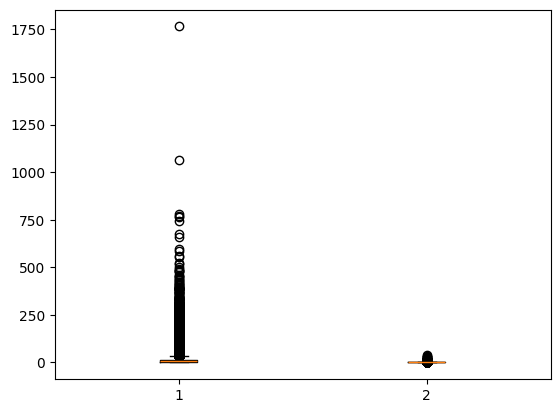

In [22]:
plt.boxplot(temp)
plt.show()

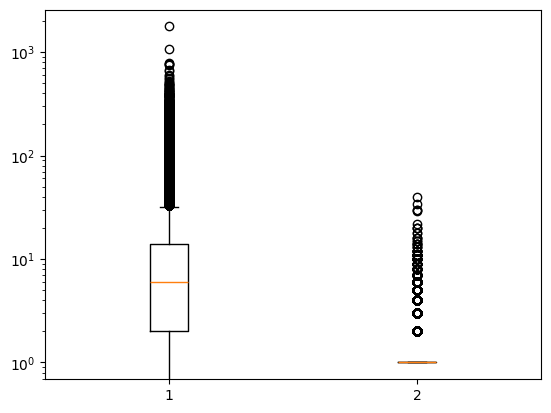

In [23]:
plt.boxplot(ns_book7[['대출건수','도서권수']])
plt.yscale('log')
plt.show()

로그 스케일을 적용해도 '도서권수' 상자가 보이지 않는 이유는 사분위수가 모두 1이라 상자 높이가 거의 없기 때문임.
반면 '대출건수'는 값 분포가 다양해서 상자 모양이 뚜렷하게 나타남.

## 상자수염그림 수평으로 그리기

여러 개의 상자수염그림을 가로 방향으로 그리고 싶다면 boxplot() 함수의 vert=False 옵션을 사용하면 됨.

이 경우 x축과 y축이 서로 바뀌기 때문에 로그 스케일도 y축이 아니라 x축에 적용해야 함.
로그 스케일 설정은 xscale() 함수를 사용함.

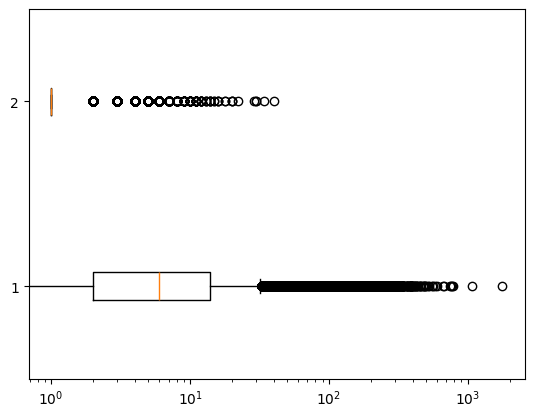

In [24]:
plt.boxplot(ns_book7[['대출건수','도서권수']], vert=False)
plt.xscale('log')
plt.show()

## 수염 길이 조정하기

기본적으로 IQR의 1.5배 범위까지 표시됨.

하지만 whis 매개변수로 이 범위를 조절할 수 있음.
예를 들어 whis=10으로 설정하면 IQR의 10배 범위 안에 있는 가장 먼 데이터까지 수염이 그려짐.

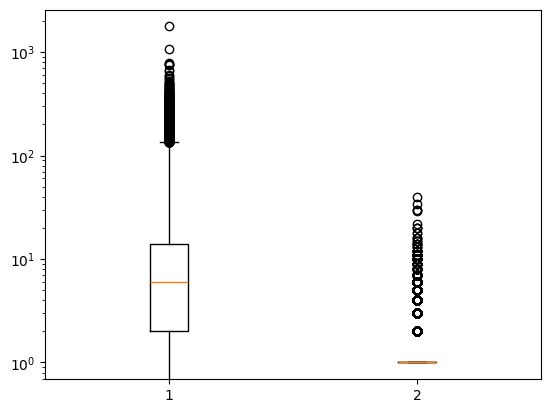

In [25]:
plt.boxplot(ns_book7[['대출건수','도서권수']], whis=10)
plt.yscale('log')
plt.show()

whis 값을 크게 지정하면 상자수염그림의 수염 길이도 더 길어짐.
그래서 대출건수 그래프에서는 이전보다 수염이 훨씬 길게 나타남.

반면 도서권수는 IQR이 0이라 여전히 수염이 거의 보이지 않음.

또 whis는 백분위 기준으로도 설정 가능함.
예를 들어 (10, 90)은 10~90% 범위까지, (0, 100)은 전체 데이터 범위까지 수염을 표시함.

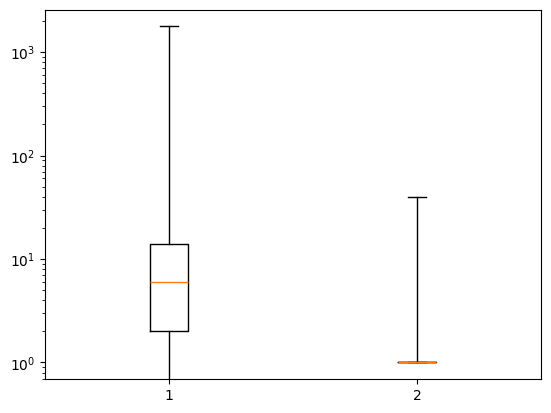

In [26]:
plt.boxplot(ns_book7[['대출건수','도서권수']], whis=(0,100))
plt.yscale('log')
plt.show()

# 판다스의 그래프 함수

판다스 데이터프레임에도 여러가지 그래프를 그릴 수 있는 메서드를 제공

## 산점도 그리기

판다스 데이터프레임 객체의 plot속성은 여러가지 그래프를 그릴 수 있는 메서드를 제공

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44428 (\N{HANGUL SYLLABLE GWEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

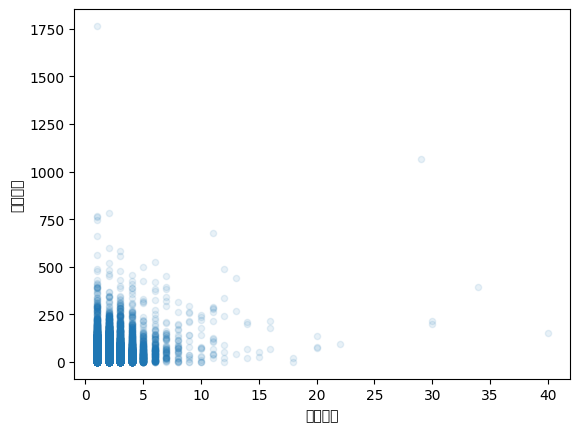

In [27]:
ns_book7.plot.scatter('도서권수', '대출건수', alpha=0.1)
plt.show()

## 히스토그램 그리기

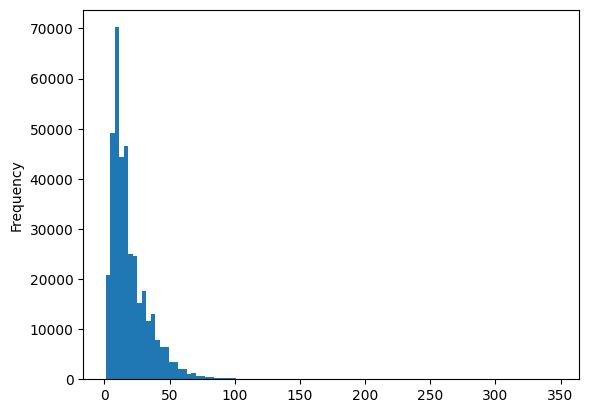

In [28]:
ns_book7['도서명'].apply(len).plot.hist(bins=100)
plt.show()

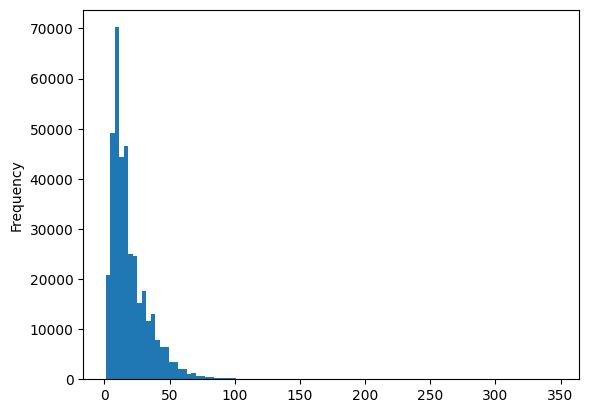

In [29]:
ns_book7['도서명'].apply(len).plot.hist(bins=100)
plt.show()

## 상자수염그림그리기

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

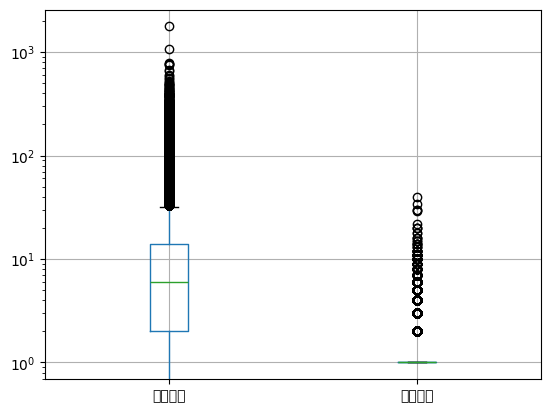

In [30]:
ns_book7[['대출건수','도서권수']].boxplot()
plt.yscale('log')
plt.show()

# 확인문제

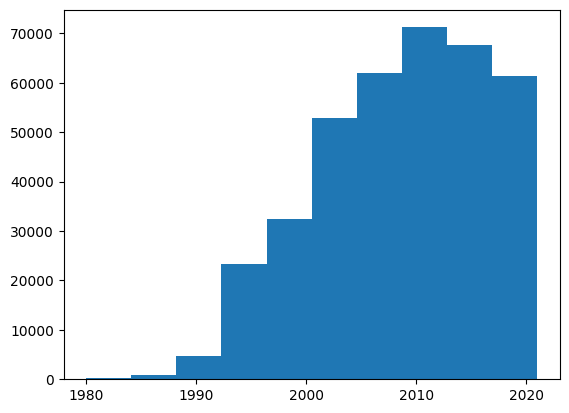

In [31]:
#4
selected_rows = (1980 <= ns_book7['발행년도']) & (ns_book7['발행년도'] <= 2022)
plt.hist(ns_book7.loc[selected_rows, '발행년도'])
plt.show()

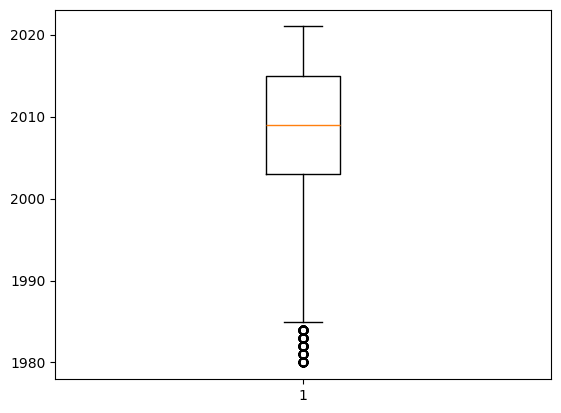

In [32]:
#5
plt.boxplot(ns_book7.loc[selected_rows, '발행년도'])
plt.show()